In [1]:
"""
analyze_tickets.py

Analyzes IT ticket/request data for trend and productivity insights.

Expected columns (flexible, defaults can be changed via CLI):
- CreateTime (epoch ms like 1.75939E+12 OR any parseable datetime)
- SLT.TargetDate (YYYYMMDD)
- AssignedToPerson.Name (for per-staff output)
- (Optional) Cost column per ticket if you prefer summing actual costs

Key outputs:
- Overall trend (slope), MoM, QoQ
- Cumulative growth since baseline (first N months)
- Acceleration (change in MoM), sustained gains
- Spike vs structural improvement (heuristic)
- Above/below target (if --monthly-target provided)
- YoY vs same period last year
- Average monthly baseline, best month historically
- Gap to peak, decline detection in Q4, recovery metrics
- Output per staff member, cost per ticket, productivity trend

Author: For Timothy Ateesa (Digital Workplace Lead)
"""


import math
from pathlib import Path
from typing import Optional, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")

In [2]:
# Cell 2: Utilities (file read, date parsing, formatting)

def smart_read(path: str) -> pd.DataFrame:
    """Read CSV/Excel robustly."""
    p = Path(path)
    if not p.exists():
        raise FileNotFoundError(f"File not found: {path}")
    if p.suffix.lower() in [".xlsx", ".xlsm", ".xltx", ".xltm", ".xls"]:
        if p.suffix.lower() == ".xls":
            df = pd.read_excel(p, engine="xlrd")
        else:
            df = pd.read_excel(p, engine="openpyxl")
    elif p.suffix.lower() in [".csv", ".txt"]:
        df = pd.read_csv(p)
    else:
        raise ValueError("Unsupported file type. Use CSV or Excel.")
    return df


def parse_mixed_datetime(s: pd.Series) -> pd.Series:
    """
    Robustly parse a date-like series:
    - If value looks like epoch milliseconds (>= 1e12), parse with unit='ms'
    - If 8-digit numbers (YYYYMMDD), parse with format='%Y%m%d'
    - Else, try pandas' to_datetime with infer
    """
    s2 = s.copy()

    # Try numeric epoch ms
    numeric = pd.to_numeric(s2, errors="coerce")
    mask_epoch_ms = numeric.notna() & (numeric >= 1e12)  # ~milliseconds since 1970
    if mask_epoch_ms.any():
        s2_epoch = pd.to_datetime(numeric[mask_epoch_ms], unit="ms", errors="coerce")
        s2.loc[mask_epoch_ms] = s2_epoch.astype("datetime64[ns]")

    # Try YYYYMMDD for 8-digit ints/strings
    s_str = s2.astype(str)
    mask_yyyymmdd = s_str.str.fullmatch(r"\d{8}", na=False)
    if mask_yyyymmdd.any():
        s2_date = pd.to_datetime(s_str[mask_yyyymmdd], format="%Y%m%d", errors="coerce")
        s2.loc[mask_yyyymmdd] = s2_date.astype("datetime64[ns]")

    # Final general parse where still not datetime
    return pd.to_datetime(s2, errors="coerce", infer_datetime_format=True)


def full_month_range_index(start: pd.Timestamp, end: pd.Timestamp) -> pd.DatetimeIndex:
    start_m = pd.Timestamp(start.year, start.month, 1)
    end_m = pd.Timestamp(end.year, end.month, 1)
    return pd.date_range(start_m, end_m, freq="MS")  # month start


def fmt_pct(x: Optional[float]) -> str:
    if x is None or (isinstance(x, float) and (np.isnan(x) or np.isinf(x))):
        return "n/a"
    return f"{x*100:.1f}%"

In [3]:
# Cell 3: Core logic (build series, growth metrics, trend, etc.)

def build_monthly_series(
    df: pd.DataFrame,
    date_col: str,
    value_col: Optional[str] = None,
) -> pd.Series:
    """
    Create monthly series y:
    - If value_col is None, y = count of rows per month
    - If value_col is provided, y = sum of value_col per month
    """
    if date_col not in df.columns:
        raise KeyError(f"Date column '{date_col}' not found in data.")
    dates = parse_mixed_datetime(df[date_col])
    df = df.assign(__dt=dates).dropna(subset=["__dt"])
    df["__month"] = df["__dt"].dt.to_period("M").dt.to_timestamp()

    if value_col is None:
        y = df.groupby("__month").size().rename("tickets")
    else:
        if value_col not in df.columns:
            raise KeyError(f"value_col '{value_col}' not found in data.")
        y = df.groupby("__month")[value_col].sum(min_count=1).rename("value")

    full_idx = full_month_range_index(y.index.min(), y.index.max())
    y = y.reindex(full_idx, fill_value=0).astype(float)
    y.index.name = "month"
    return y


def compute_mom_qoq(y: pd.Series) -> Tuple[pd.Series, pd.Series]:
    mom = y.pct_change()  # month over month
    q = y.resample("Q").sum()
    qoq = q.pct_change()
    return mom, qoq


def regression_slope(y: pd.Series) -> float:
    """
    Linear trend slope per month (units of y per month)
    """
    if len(y.dropna()) < 2:
        return np.nan
    x = np.arange(len(y))
    coeffs = np.polyfit(x, y.values, 1)
    return float(coeffs[0])  # slope


def sustained_positive_streak(mom: pd.Series) -> int:
    """
    Longest consecutive positive MoM streak length
    """
    best = curr = 0
    for val in mom:
        if pd.notna(val) and val > 0:
            curr += 1
            best = max(best, curr)
        else:
            curr = 0
    return best


def cumulative_growth_since_baseline(y: pd.Series, baseline_months: int = 3) -> pd.Series:
    if baseline_months < 1:
        baseline_months = 1
    baseline = y.iloc[:baseline_months].mean()
    if baseline == 0 or np.isnan(baseline):
        return pd.Series(index=y.index, dtype=float)
    return (y / baseline) - 1.0


def acceleration_metric(mom: pd.Series) -> float:
    """
    Average change in MoM (i.e., second-order trend)
    """
    d = mom.diff()
    return float(d.mean(skipna=True))


def compounding_indicator(mom: pd.Series) -> Dict[str, Optional[float]]:
    """
    Compare geometric mean growth vs arithmetic mean;
    Compute compounded growth over entire series.
    """
    m = mom.dropna()
    if len(m) == 0:
        return {"arith_mean": None, "geom_mean": None, "total_compounded": None}
    arith_mean = float(m.mean())
    with np.errstate(invalid="ignore"):
        product = float(np.prod(1 + m))
    geom_mean = None
    if len(m) > 0 and product > 0:
        geom_mean = product ** (1 / len(m)) - 1
    total_compounded = product - 1 if product is not None else None
    return {
        "arith_mean": arith_mean,
        "geom_mean": geom_mean,
        "total_compounded": total_compounded,
    }


def detect_spike_vs_structural(
    y: pd.Series, lookback: int = 6, forward: int = 3, pct_threshold: float = 0.30
) -> Dict[str, object]:
    """
    Heuristic:
    - Find month with max deviation from prior 'lookback' mean.
    - If that month exceeds prior mean by > pct_threshold, it's a spike candidate.
    - Compare post 'forward' average vs pre lookback average.
      If post >= pre * (1 + pct_threshold/2), call 'structural'.
    """
    if len(y) < (lookback + forward + 1):
        return {"spike_month": None, "classification": "insufficient_data"}

    rolling_pre = y.rolling(lookback, min_periods=lookback).mean().shift(1)
    deviation = y / rolling_pre - 1
    spike_month = deviation.idxmax() if deviation.notna().any() else None

    if spike_month is None or pd.isna(deviation.loc[spike_month]):
        return {"spike_month": None, "classification": "no_spike_detected"}

    if deviation.loc[spike_month] < pct_threshold:
        return {"spike_month": spike_month, "classification": "no_spike_detected"}

    # Pre and post means
    pre_end = spike_month - pd.offsets.MonthBegin(1)
    pre_start = pre_end - pd.DateOffset(months=lookback - 1)
    post_start = spike_month + pd.offsets.MonthBegin(1)
    post_end = post_start + pd.DateOffset(months=forward - 1)

    pre_avg = y.loc[(y.index >= pre_start) & (y.index <= pre_end)].mean()
    post_avg = y.loc[(y.index >= post_start) & (y.index <= post_end)].mean()

    if pd.isna(pre_avg) or pd.isna(post_avg) or pre_avg == 0:
        return {"spike_month": spike_month, "classification": "inconclusive"}

    classification = (
        "structural_improvement" if post_avg >= pre_avg * (1 + pct_threshold / 2) else "temporary_spike"
    )
    return {
        "spike_month": spike_month,
        "classification": classification,
        "pre_avg": pre_avg,
        "post_avg": post_avg,
        "post_vs_pre_pct": (post_avg - pre_avg) / pre_avg,
    }


def yoy_same_period(y: pd.Series) -> Dict[str, Optional[float]]:
    """
    Compare YTD vs same period last year, and last month vs same month last year.
    """
    if len(y) < 13:
        return {"ytd_vs_last_year": None, "last_month_yoy": None}

    last_month = y.index.max()
    same_month_ly = last_month - pd.DateOffset(years=1)

    last_month_yoy = None
    if same_month_ly in y.index and y.loc[same_month_ly] != 0:
        last_month_yoy = (y.loc[last_month] - y.loc[same_month_ly]) / y.loc[same_month_ly]

    # YTD vs same period last year
    months_so_far = last_month.month
    this_year = last_month.year
    ytd_this = y[(y.index.year == this_year) & (y.index.month <= months_so_far)].sum()
    ytd_last = y[(y.index.year == (this_year - 1)) & (y.index.month <= months_so_far)].sum()
    ytd_vs_last_year = None
    if ytd_last not in [0, None, np.nan]:
        ytd_vs_last_year = (ytd_this - ytd_last) / ytd_last

    return {"ytd_vs_last_year": ytd_vs_last_year, "last_month_yoy": last_month_yoy}


def q4_decline_drivers(
    df: pd.DataFrame,
    date_col: str,
    category_cols: Tuple[str, ...] = ("Priority", "EntityType", "AssignedToGroup.Name", "AssignedToPerson.Name"),
) -> Dict[str, object]:
    """
    If latest full year has Q3 -> Q4 decline, compute contribution by categories.
    """
    dates = parse_mixed_datetime(df[date_col])
    df = df.assign(__dt=dates).dropna(subset=["__dt"])
    df["__month"] = df["__dt"].dt.to_period("M").dt.to_timestamp()
    df["__quarter"] = df["__dt"].dt.to_period("Q")

    q_counts = df.groupby(df["__dt"].dt.to_period("Q")).size()
    if len(q_counts) < 4:
        return {"decline_detected": False, "reason": "insufficient_quarter_data"}

    q_counts = q_counts.sort_index()
    latest_year = q_counts.index[-1].year
    year_quarters = q_counts[q_counts.index.year == latest_year]
    if len(year_quarters) < 4:
        latest_year -= 1
        year_quarters = q_counts[q_counts.index.year == latest_year]
        if len(year_quarters) < 4:
            return {"decline_detected": False, "reason": "no_full_year_found"}

    # Compare Q3 -> Q4
    try:
        q3 = year_quarters[year_quarters.index.quarter == 3].iloc[0]
        q4 = year_quarters[year_quarters.index.quarter == 4].iloc[0]
    except Exception:
        return {"decline_detected": False, "reason": "q3_q4_not_found"}

    decline = q4 < q3
    if not decline:
        return {"decline_detected": False, "reason": "no_q4_decline"}

    q3_mask = (df["__dt"].dt.year == latest_year) & (df["__dt"].dt.quarter == 3)
    q4_mask = (df["__dt"].dt.year == latest_year) & (df["__dt"].dt.quarter == 4)

    drivers = {}
    for col in category_cols:
        if col in df.columns:
            c_q3 = df.loc[q3_mask, col].value_counts()
            c_q4 = df.loc[q4_mask, col].value_counts()
            all_idx = c_q3.index.union(c_q4.index)
            comp = pd.DataFrame(
                {"Q3": c_q3.reindex(all_idx, fill_value=0), "Q4": c_q4.reindex(all_idx, fill_value=0)}
            )
            comp["Delta(Q4-Q3)"] = comp["Q4"] - comp["Q3"]
            comp = comp.sort_values("Delta(Q4-Q3)")
            drivers[col] = comp.head(10)  # top drops
    return {
        "decline_detected": True,
        "latest_year": latest_year,
        "q3_total": int(q3),
        "q4_total": int(q4),
        "drivers": drivers,
    }


def recovery_metrics(y: pd.Series, pre_decline_peak_window_months: int = 6) -> Dict[str, object]:
    """
    Detect a decline and measure recovery:
    - Peak: global max
    - Trough: lowest point after peak
    - Recovery: first month after trough where y >= pre-peak
    """
    if len(y) < (pre_decline_peak_window_months + 3):
        return {"recovery_found": False, "reason": "insufficient_data"}

    pre_peak_idx = y.idxmax()
    if pre_peak_idx is None:
        return {"recovery_found": False, "reason": "no_peak"}

    post = y[y.index > pre_peak_idx]
    if len(post) == 0:
        return {"recovery_found": False, "reason": "no_post_peak_data"}
    trough_idx = post.idxmin()
    pre_peak_val = float(y.loc[pre_peak_idx])
    trough_val = float(y.loc[trough_idx])

    post_trough = y[y.index > trough_idx]
    recovery_idx = None
    for idx, val in post_trough.items():
        if val >= pre_peak_val:
            recovery_idx = idx
            break

    months_to_recover = None
    pct_growth_required = None
    surpassed = False
    if recovery_idx is not None:
        months_to_recover = (recovery_idx.year - trough_idx.year) * 12 + (recovery_idx.month - trough_idx.month)
        surpassed = True

    if trough_val > 0:
        pct_growth_required = (pre_peak_val - trough_val) / trough_val

    return {
        "recovery_found": recovery_idx is not None,
        "peak_month": pre_peak_idx,
        "peak_value": pre_peak_val,
        "trough_month": trough_idx,
        "trough_value": trough_val,
        "recovery_month": recovery_idx,
        "months_to_recover": months_to_recover,
        "pct_growth_required": pct_growth_required,
        "surpassed_pre_decline": surpassed,
    }


def output_per_staff(df: pd.DataFrame, date_col: str, staff_col: str) -> pd.DataFrame:
    dates = parse_mixed_datetime(df[date_col])
    df = df.assign(__dt=dates).dropna(subset=["__dt"])
    df["month"] = df["__dt"].dt.to_period("M").dt.to_timestamp()
    if staff_col not in df.columns:
        raise KeyError(f"Staff column '{staff_col}' not found in data.")
    tbl = df.groupby(["month", staff_col]).size().rename("tickets").reset_index()
    return tbl


def productivity_trend(y: pd.Series, staff_tbl: pd.DataFrame) -> Tuple[pd.Series, float]:
    """
    Productivity = tickets per active staff per month.
    Active staff in a month = count of staff with >=1 ticket that month.
    Returns (series, linear slope).
    """
    # staff_tbl columns: ["month", staff_col, "tickets"]
    staff_col = staff_tbl.columns[1]
    active_staff = staff_tbl.groupby("month")[staff_col].nunique()
    active_staff = active_staff.reindex(y.index, fill_value=0)
    prod = pd.Series(index=y.index, dtype=float, name="tickets_per_active_staff")
    with np.errstate(divide="ignore", invalid="ignore"):
        prod[:] = np.where(active_staff > 0, y.values / active_staff.values, np.nan)

    slope = regression_slope(prod.dropna())
    return prod, slope


def cost_per_ticket_series(
    y: pd.Series,
    monthly_cost: Optional[float],
    df: Optional[pd.DataFrame],
    date_col: str,
    cost_col: Optional[str],
) -> pd.Series:
    """
    If monthly_cost provided, cost_per_ticket = monthly_cost / monthly_tickets.
    If cost_col provided (per ticket), sum monthly to get cost per month then divide.
    """
    if monthly_cost is None and (cost_col is None or df is None):
        return pd.Series(index=y.index, dtype=float, name="cost_per_ticket")

    monthly_costs = pd.Series(index=y.index, dtype=float, name="monthly_cost")

    if cost_col and df is not None and (cost_col in df.columns):
        dates = parse_mixed_datetime(df[date_col])
        df2 = df.assign(__dt=dates).dropna(subset=["__dt"])
        df2["month"] = df2["__dt"].dt.to_period("M").dt.to_timestamp()
        monthly_costs = df2.groupby("month")[cost_col].sum(min_count=1)
        monthly_costs = monthly_costs.reindex(y.index, fill_value=np.nan)
    elif monthly_cost is not None:
        monthly_costs[:] = monthly_cost

    with np.errstate(divide="ignore", invalid="ignore"):
        cpt = monthly_costs / y.replace({0: np.nan})
    cpt.name = "cost_per_ticket"
    return cpt

In [4]:
# Cell 4: Orchestrator for notebooks

def analyze_tickets_notebook(
    df: pd.DataFrame,
    *,
    date_col: str = "CreateTime",
    value_col: Optional[str] = None,
    staff_col: str = "AssignedToPerson.Name",
    cost_col: Optional[str] = None,
    monthly_cost: Optional[float] = None,
    monthly_target: Optional[float] = None,
    baseline_months: int = 3,
    make_plots: bool = True,
) -> Dict[str, object]:
    """
    Runs the full analysis and returns a dict of results suitable for interactive notebooks.
    """
    # Build monthly series (tickets by default)
    y = build_monthly_series(df, date_col=date_col, value_col=value_col)
    mom, qoq = compute_mom_qoq(y)
    slope = regression_slope(y)
    acc = acceleration_metric(mom)
    streak = sustained_positive_streak(mom)
    cum_growth = cumulative_growth_since_baseline(y, baseline_months=baseline_months)
    comp = compounding_indicator(mom)
    spike = detect_spike_vs_structural(y)
    yoy = yoy_same_period(y)
    rec = recovery_metrics(y)

    # Above/below target
    last_month = y.index.max()
    last_y = y.loc[last_month] if len(y) else np.nan
    target_str = "n/a"
    above_below = "n/a"
    target_gap_pct = None
    if monthly_target is not None and not np.isnan(last_y):
        target_str = f"{monthly_target:.0f}"
        if monthly_target > 0:
            target_gap_pct = (last_y - monthly_target) / monthly_target
            above_below = "above" if last_y >= monthly_target else "below"

    # Best month & gap to peak
    best_month = y.idxmax() if len(y) else None
    best_value = float(y.max()) if len(y) else np.nan
    gap_to_peak = None
    if best_value not in [0, np.nan] and not np.isnan(best_value):
        gap_to_peak = (best_value - last_y) / best_value if best_value != 0 else None

    # Q4 decline drivers
    q4 = q4_decline_drivers(df, date_col=date_col)

    # Output per staff & productivity
    staff_tbl = output_per_staff(df, date_col=date_col, staff_col=staff_col)
    prod_series, prod_slope = productivity_trend(y, staff_tbl)

    # Cost per ticket
    cpt = cost_per_ticket_series(y, monthly_cost, df, date_col, cost_col)

    # ---- Summary printout ----
    print("\n==================== SUMMARY ====================")
    print(f"Data range: {y.index.min().date()} to {y.index.max().date()}  |  Months: {len(y)}")
    print(f"Overall trend slope (tickets/month): {slope:.2f}  -> {'Positive' if slope > 0 else 'Negative' if slope < 0 else 'Flat'}")
    print(f"Is overall trend increasing? {'Yes' if slope > 0 else 'No' if slope < 0 else 'Flat'}")
    print(f"Latest month: {last_month.strftime('%Y-%m')}  |  Tickets: {int(last_y) if not np.isnan(last_y) else 'n/a'}")
    print(f"MoM (latest): {fmt_pct(mom.iloc[-1])}")
    q_series = y.resample('Q').sum()
    if len(q_series) >= 2:
        print(f"QoQ (latest): {fmt_pct(q_series.pct_change().iloc[-1])}")
    else:
        print(f"QoQ (latest): n/a")
    print(f"Cumulative growth since baseline (latest): {fmt_pct(cum_growth.iloc[-1] if len(cum_growth) else None)}")
    print(f"Is growth accelerating? {'Yes' if acc and acc>0 else 'No' if acc and acc<0 else 'Inconclusive'} (avg ΔMoM = {fmt_pct(acc)})")
    print(f"Sustained gains: longest positive MoM streak = {streak} months")
    print(f"Compounding: total compounded growth over series = {fmt_pct(comp.get('total_compounded'))}")
    print(f"Spike vs structural: {spike.get('classification')} (spike month: {spike.get('spike_month').strftime('%Y-%m') if spike.get('spike_month') else 'n/a'})")
    print(f"Above/below target ({target_str}): {above_below} ({fmt_pct(target_gap_pct)})")
    print(f"YoY last month: {fmt_pct(yoy.get('last_month_yoy'))} | YTD vs LY: {fmt_pct(yoy.get('ytd_vs_last_year'))}")
    baseline_avg = y.iloc[:max(1, baseline_months)].mean() if len(y) else np.nan
    print(f"Average monthly baseline (first {baseline_months} months): {baseline_avg:.2f}")
    if best_month is not None:
        print(f"Best month historically: {best_month.strftime('%Y-%m')} with {int(best_value)} tickets")
        print(f"Gap between current and peak: {fmt_pct(gap_to_peak)}")
    # Q4 info
    if q4.get("decline_detected", False):
        print(f"Q4 decline detected in {q4.get('latest_year')}: Q3={q4.get('q3_total')} -> Q4={q4.get('q4_total')} (Δ={q4.get('q4_total') - q4.get('q3_total')})")
        print("Top drop drivers tables are available in results['q4']['drivers'] (by category).")
    else:
        print("Q4 decline: not detected (or insufficient data).")
    # Recovery
    if rec.get("peak_month") is not None:
        print(f"Pre-decline peak: {rec['peak_month'].strftime('%Y-%m')} (value={rec['peak_value']:.0f})")
    if rec.get("trough_month") is not None:
        print(f"Trough after peak: {rec['trough_month'].strftime('%Y-%m')} (value={rec['trough_value']:.0f})")
    print(f"Recovered to pre-decline? {'Yes' if rec.get('recovery_found') else 'No'}")
    if rec.get("recovery_month") is not None:
        print(f"Recovery month: {rec['recovery_month'].strftime('%Y-%m')} | Months to recover: {rec.get('months_to_recover')}")
    print(f"% growth required to recover (from trough to peak): {fmt_pct(rec.get('pct_growth_required'))}")
    # Productivity & cost
    print(f"Productivity slope (tickets per active staff per month): {prod_slope:.3f}  -> {'Improving' if prod_slope and prod_slope>0 else 'Worsening' if prod_slope and prod_slope<0 else 'Flat/Inconclusive'}")
    if not cpt.dropna().empty:
        latest_cpt = cpt.dropna().iloc[-1]
        print(f"Cost per ticket (latest): {latest_cpt:.2f}")
    print("=================================================\n")

    # ---- Inline plots (optional) ----
    if make_plots:
        fig, axes = plt.subplots(3, 1, figsize=(10, 12), constrained_layout=True)
        y.plot(ax=axes[0], marker="o", title="Monthly Tickets")
        axes[0].set_ylabel("Tickets")

        mom.mul(100).plot(kind="bar", ax=axes[1], title="MoM Growth (%)", color="#2a9d8f")
        axes[1].axhline(0, color="black", linewidth=0.8)

        prod_series.plot(ax=axes[2], marker="o", title="Productivity: Tickets per Active Staff", color="#e76f51")
        axes[2].set_ylabel("Tickets per staff")
        plt.show()

    # Package results
    results = {
        "monthly_series": y,
        "mom": mom,
        "qoq": qoq,
        "trend_slope": slope,
        "acceleration_avg_delta_mom": acc,
        "positive_mom_streak": streak,
        "cumulative_growth_vs_baseline": cum_growth,
        "compounding": comp,
        "spike_vs_structural": spike,
        "yoy": yoy,
        "baseline_avg": baseline_avg,
        "best_month": best_month,
        "best_value": best_value,
        "gap_to_peak": gap_to_peak,
        "q4": q4,
        "recovery": rec,
        "output_per_staff": staff_tbl,
        "productivity_series": prod_series,
        "productivity_slope": prod_slope,
        "cost_per_ticket": cpt,
        "last_month": last_month,
        "last_value": last_y,
        "target_gap_pct": target_gap_pct,
        "above_below_target": above_below,
        "monthly_target": monthly_target,
    }
    return results

In [7]:
ls

 Volume in drive C is Windows
 Volume Serial Number is 287F-ECA9

 Directory of C:\Users\tateesa\Box\DIGITAL WORK PLACE\FY2026\Documents\MoM Analyst

03/04/2026  01:47 PM    <DIR>          .
03/04/2026  01:47 PM    <DIR>          ..
03/04/2026  01:33 PM    <DIR>          .ipynb_checkpoints
03/04/2026  01:45 PM            30,141 MoM SMAX Analysis.ipynb
03/04/2026  01:10 PM           296,610 Request_20260304_1010302318309310430531382643.csv
               2 File(s)        330,847 bytes
               3 Dir(s)  47,192,293,376 bytes free


In [8]:
# Cell 5: Load your data
file_path = "Request_20260304_1010302318309310430531382643.csv"  # or "your_data.csv"
df = smart_read(file_path)
df.head()


,Id,EntityType,DisplayLabel,Priority,SLT.TargetDate,RequestedForPerson,RequestedForPerson.Name,ChatStatus,CurrentAssignment,AssignedToGroup,AssignedToGroup.Name,AssignedToPerson.Name,Status,CreateTime,UUID
0,27872711,Request,BOX // UGAO// sam_atamati@wvi.org,LowPriority,NaN,20270813,Sam Atamati,ChatStatusNone,ServiceDesk,46589,NO Uganda IT Support,Alex Senyondwa,RequestStatusComplete,1759390204480,NaN
1,27875013,Request,MS team not working,LowPriority,NaN,18951676,Allan Oketayot,ChatStatusNone,ServiceDesk,46589,NO Uganda IT Support,Kamilo Abura,RequestStatusComplete,1759393114343,NaN
2,27877936,Request,BOX // UGAO // account creation // Lawrencia_K...,MediumPriority,NaN,14070117,Lawrencia Kpacite,ChatStatusNone,ServiceDesk,46589,NO Uganda IT Support,Alex Senyondwa,RequestStatusComplete,1759395260423,NaN
3,27881230,Request,laptop configuration,LowPriority,NaN,873365,Robert Tamale,ChatStatusNone,ServiceDesk,46589,NO Uganda IT Support,Kamilo Abura,RequestStatusComplete,1759398314670,NaN
4,27881265,Request,laptop configuration,LowPriority,NaN,20270813,Sam Atamati,ChatStatusNone,ServiceDesk,46589,NO Uganda IT Support,Kamilo Abura,RequestStatusComplete,1759398492663,NaN


C:\Users\tateesa\AppData\Local\Temp\ipykernel_44376\3029528186.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '<DatetimeArray>
['2025-10-02 07:30:04.480000', '2025-10-02 08:18:34.343000',
 '2025-10-02 08:54:20.423000', '2025-10-02 09:45:14.670000',
 '2025-10-02 09:48:12.663000', '2025-10-02 10:04:33.072000',
 '2025-10-02 11:31:58.867000', '2025-10-03 08:11:21.025000',
 '2025-10-06 07:41:39.043000', '2025-10-06 07:46:47.199000',
 ...
 '2026-03-04 09:55:12.063000', '2026-03-04 09:55:21.116000',
 '2026-03-04 09:58:43.455000', '2026-03-04 09:57:31.211000',
 '2026-03-04 09:59:56.575000', '2026-03-04 10:02:58.017000',
 '2026-03-04 10:05:04.161000', '2026-03-04 10:07:11.757000',
 '2026-03-04 10:08:25.688000', '2026-03-04 10:09:31.372000']
Length: 1283, dtype: datetime64[ns]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  s2.loc[mask_epoch_ms] = s2_epoch.astype("dat


==================== SUMMARY ====================
Data range: 2025-10-01 to 2026-03-01  |  Months: 6
Overall trend slope (tickets/month): 3.23  -> Positive
Is overall trend increasing? Yes
Latest month: 2026-03  |  Tickets: 93
MoM (latest): -79.1%
QoQ (latest): 26.7%
Cumulative growth since baseline (latest): -50.7%
Is growth accelerating? No (avg ΔMoM = -10.7%)
Sustained gains: longest positive MoM streak = 3 months
Compounding: total compounded growth over series = -62.3%
Spike vs structural: insufficient_data (spike month: n/a)
Above/below target (n/a): n/a (n/a)
YoY last month: n/a | YTD vs LY: n/a
Average monthly baseline (first 3 months): 188.67
Best month historically: 2026-02 with 446 tickets
Gap between current and peak: 79.1%
Q4 decline: not detected (or insufficient data).
Recovered to pre-decline? No
% growth required to recover (from trough to peak): n/a
Productivity slope (tickets per active staff per month): 1.491  -> Improving



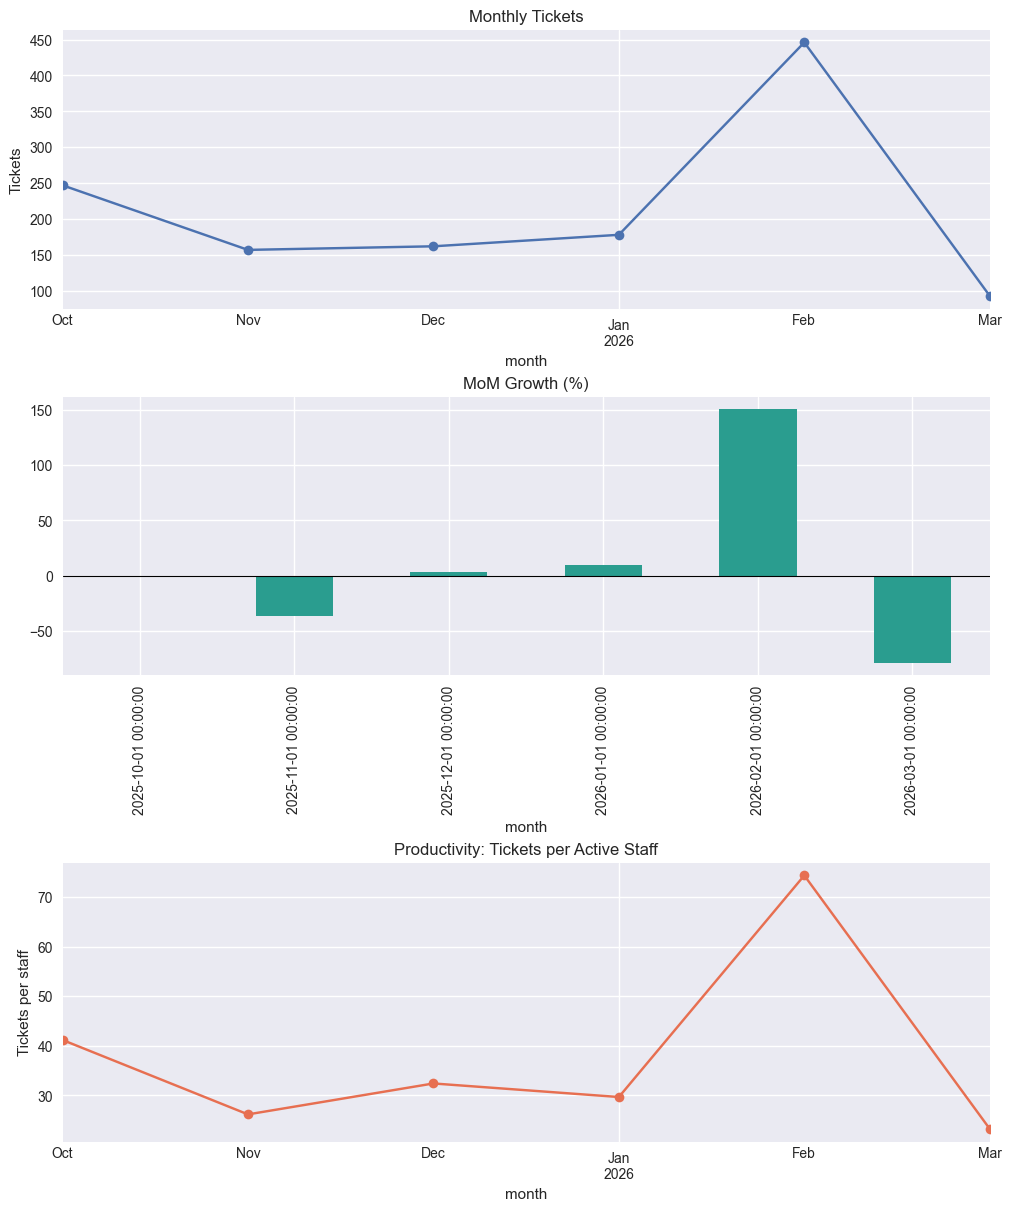

In [9]:
# Cell 6: Run analysis (using CreateTime).
results = analyze_tickets_notebook(
    df,
    date_col="CreateTime",             # or "SLT.TargetDate"
    value_col=None,                    # None -> count rows; or pass a numeric col to sum
    staff_col="AssignedToPerson.Name", # for productivity/output per staff
    cost_col=None,                     # or pass a per-ticket numeric cost column name
    monthly_cost=None,                 # or a fixed monthly cost (e.g., 5000.0)
    monthly_target=None,               # e.g., 120
    baseline_months=3,
    make_plots=True,                   # show inline plots
)

In [10]:
# Cell 7: Inspect specific answers quickly

y = results["monthly_series"]
mom = results["mom"]
qoq = results["qoq"]

print("Is the overall trend increasing over time?",
      "Yes" if results["trend_slope"] > 0 else "No" if results["trend_slope"] < 0 else "Flat")

print("MoM (latest):", fmt_pct(mom.iloc[-1]))
if len(qoq) >= 2:
    print("QoQ (latest):", fmt_pct(qoq.iloc[-1]))
print("Cumulative growth since baseline (latest):",
      fmt_pct(results["cumulative_growth_vs_baseline"].iloc[-1] if not results["cumulative_growth_vs_baseline"].empty else None))
print("Is growth accelerating or slowing?",
      "Accelerating" if (results["acceleration_avg_delta_mom"] and results["acceleration_avg_delta_mom"] > 0)
      else "Slowing" if (results["acceleration_avg_delta_mom"] and results["acceleration_avg_delta_mom"] < 0)
      else "Inconclusive")
print("Trend slope:", f"{results['trend_slope']:.2f} per month",
      "| Are increases larger each month?", 
      "Some evidence" if (results["acceleration_avg_delta_mom"] and results["acceleration_avg_delta_mom"] > 0) else "Not consistently")
print("Sustained gains (longest positive MoM streak):", results["positive_mom_streak"], "months")
print("Are growth rates compounding? Total compounded growth:", fmt_pct(results["compounding"].get("total_compounded")))
print("Spike vs structural improvement:", results["spike_vs_structural"]["classification"])
print("Above or below target:", results["above_below_target"], "| Gap:", fmt_pct(results["target_gap_pct"]))
print("Outperforming last year same period? YTD vs LY:", fmt_pct(results["yoy"].get("ytd_vs_last_year")))
print("Average monthly baseline:", f"{results['baseline_avg']:.2f}")
print("Best month historically:", results["best_month"])
print("Gap between current and peak:", fmt_pct(results["gap_to_peak"]))
print("Recovery found?", "Yes" if results["recovery"]["recovery_found"] else "No")
print("Months to recover:", results["recovery"].get("months_to_recover"))
print("% growth required to recover:", fmt_pct(results["recovery"].get("pct_growth_required")))
print("Did performance surpass pre-decline?", "Yes" if results["recovery"].get("surpassed_pre_decline") else "No")


Is the overall trend increasing over time? Yes
MoM (latest): -79.1%
QoQ (latest): 26.7%
Cumulative growth since baseline (latest): -50.7%
Is growth accelerating or slowing? Slowing
Trend slope: 3.23 per month | Are increases larger each month? Not consistently
Sustained gains (longest positive MoM streak): 3 months
Are growth rates compounding? Total compounded growth: -62.3%
Spike vs structural improvement: insufficient_data
Above or below target: n/a | Gap: n/a
Outperforming last year same period? YTD vs LY: n/a
Average monthly baseline: 188.67
Best month historically: 2026-02-01 00:00:00
Gap between current and peak: 79.1%
Recovery found? No
Months to recover: None
% growth required to recover: n/a
Did performance surpass pre-decline? No
